# Notebook 3: Exploratory data analysis (EDA)

This notebook performs exploratory analyses for reporting (distributions, missingness, correlations, descriptive plots) on the cleaned neighbourhood-level dataset.

### Input
- `datasets/pre-processing/cleaned_crime_nbh_2024.csv`

### Outputs
- No datasets are written by default; figures are generated inline.


### Loading packages and datset

In [171]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PREPROC_DIR = Path("datasets/pre-processing")
PREPROC_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(
    PREPROC_DIR / "cleaned_crime_nbh_2024.csv",
    low_memory=False,
    dtype={"gwb_code_10": "string", "regio": "string", "gm_naam": "string"},
)

In [172]:
df.shape

(14494, 123)

### Uniqueness of Index column

In [173]:
df["gwb_code_10"].isna().sum(), df["gwb_code_10"].duplicated().sum()

(np.int64(0), np.int64(0))

### Column types overview

In [174]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print(f"Number of numeric columns: {len(num_cols)}")
print(f"Number of non-numeric columns: {len(cat_cols)}")
print("Numeric columns (first 10):", num_cols[:10])
print("Numeric columns (last 10):", num_cols[-10:])
print("Non-numeric columns (first 10):", cat_cols[:10])

Number of numeric columns: 120
Number of non-numeric columns: 3
Numeric columns (first 10): ['a_inw', 'a_man', 'a_vrouw', 'a_00_14', 'a_15_24', 'a_25_44', 'a_45_64', 'a_65_oo', 'a_ongeh', 'a_gehuwd']
Numeric columns (last 10): ['g_afs_sc', 'g_3km_sc', 'a_opp_ha', 'a_lan_ha', 'a_wat_ha', 'pst_mvp', 'pst_dekp', 'ste_mvs', 'ste_oad', 'GeregistreerdeMisdrijven_1']
Non-numeric columns (first 10): ['gwb_code_10', 'regio', 'gm_naam']


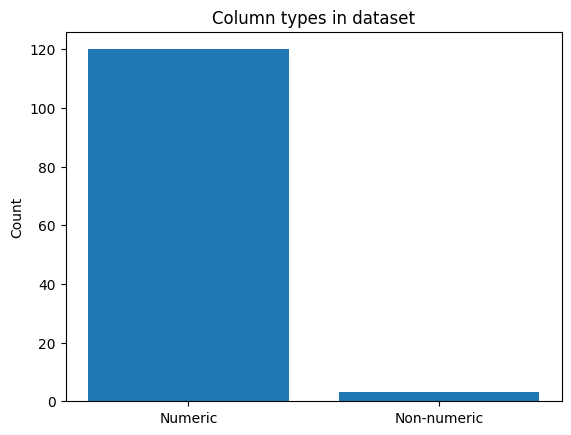

In [175]:
plt.figure()
plt.bar(["Numeric", "Non-numeric"], [len(num_cols), len(cat_cols)])
plt.title("Column types in dataset")
plt.ylabel("Count")
plt.show()


## Target Variable

In [176]:
df["GeregistreerdeMisdrijven_1"].describe()

count    14494.000000
mean        54.725611
std        121.275987
min          0.000000
25%          8.000000
50%         22.000000
75%         57.000000
max       3714.000000
Name: GeregistreerdeMisdrijven_1, dtype: float64

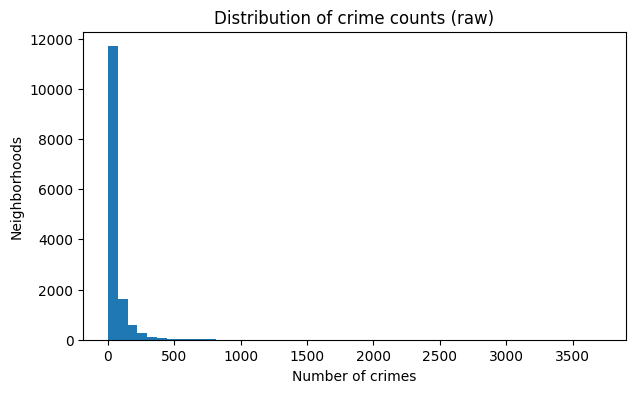

In [177]:
plt.figure(figsize=(7,4))
plt.hist(df["GeregistreerdeMisdrijven_1"], bins=50)
plt.title("Distribution of crime counts (raw)")
plt.xlabel("Number of crimes")
plt.ylabel("Neighborhoods")
plt.show()


### Applying log-transformation to target variable for EDA purposes. Dataset remains unchanged.

In [178]:
# Create 'crime_count' and create log-transformed crime count column named 'log_crime_count'

df["crime_count"] = pd.to_numeric(df["GeregistreerdeMisdrijven_1"], errors="coerce").astype(float)
df["log_crime_count"] = np.log1p(np.clip(df["crime_count"], 0, None))

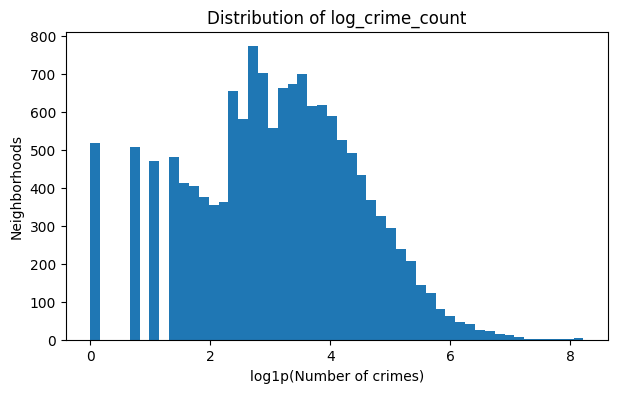

In [179]:
plt.figure(figsize=(7,4))
plt.hist((df["log_crime_count"]), bins=50)
plt.title("Distribution of log_crime_count")
plt.xlabel("log1p(Number of crimes)")
plt.ylabel("Neighborhoods")
plt.show()


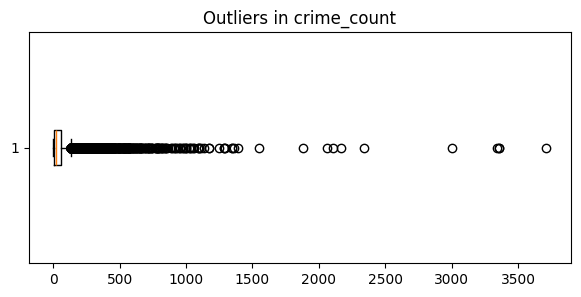

In [180]:
plt.figure(figsize=(7,3))
plt.boxplot(df["crime_count"], vert=False)
plt.title("Outliers in crime_count")
plt.show()

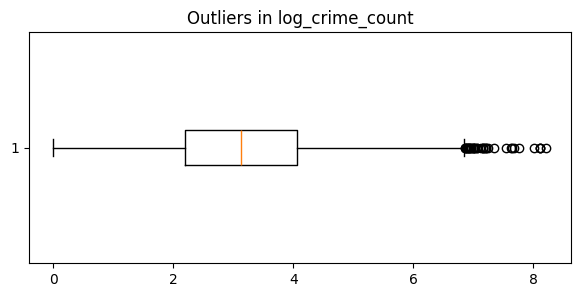

In [181]:
plt.figure(figsize=(7,3))
plt.boxplot(df["log_crime_count"], vert=False)
plt.title("Outliers in log_crime_count")
plt.show()

## Missing Data

In [182]:
# Missingness rate per column (share of NaNs)
miss = df.isna().mean()

In [201]:
# Count columns by missingness buckets, excluding specified columns
exclude_cols = ["gwb_code_10", "regio", "gm_naam", "GeregistreerdeMisdrijven_1", "crime_count", "log_crime_count"]
miss_filtered = miss[~miss.index.isin(exclude_cols)]

n_100 = (miss_filtered >= 0.999).sum()
n_15_99 = ((miss_filtered >= 0.15) & (miss_filtered < 0.999)).sum()
n_10_15 = ((miss_filtered >= 0.10) & (miss_filtered < 0.15)).sum()
n_1_9 = ((miss_filtered >= 0.01) & (miss_filtered < 0.10)).sum()
n_less0 = ((miss_filtered < 0.01) & (miss_filtered > 0)).sum()
n_0 = (miss_filtered == 0).sum()

print(f"Columns with 100% missing: {n_100}")
print(f"Columns with 15-99% missing: {n_15_99}")
print(f"Columns with 10-15% missing: {n_10_15}")
print(f"Columns with 1-9% missing: {n_1_9}")
print(f"Columns with <1% missing: {n_less0}")
print(f"Columns with 0 missing: {n_0}")
print(f"Total columns (candidate predictors only): {len(miss_filtered)}")
print()

n_100 = (miss >= 0.999).sum()
n_15_99 = ((miss >= 0.15) & (miss < 0.999)).sum()
n_10_15 = ((miss >= 0.10) & (miss < 0.15)).sum()
n_1_9 = ((miss >= 0.01) & (miss < 0.10)).sum()
n_less0 = ((miss < 0.01) & (miss > 0)).sum()
n_0 = (miss == 0).sum()

print(f"Columns with 100% missing: {n_100}")
print(f"Columns with 15-99% missing: {n_15_99}")
print(f"Columns with 10-15% missing: {n_10_15}")
print(f"Columns with 1-9% missing: {n_1_9}")
print(f"Columns with <1% missing: {n_less0}")
print(f"Columns with 0 missing: {n_0}")
print(f"Total columns: {len(df.columns)}")

Columns with 100% missing: 27
Columns with 15-99% missing: 7
Columns with 10-15% missing: 26
Columns with 1-9% missing: 10
Columns with <1% missing: 6
Columns with 0 missing: 43
Total columns (candidate predictors only): 119

Columns with 100% missing: 27
Columns with 15-99% missing: 7
Columns with 10-15% missing: 26
Columns with 1-9% missing: 10
Columns with <1% missing: 6
Columns with 0 missing: 49
Total columns: 125


In [184]:
miss = df.isna().mean().sort_values(ascending=False)
miss.head(30)

m_hh_ver       1.000000
p_arb_zs       1.000000
a_lp_pub       1.000000
a_wmo_t        1.000000
p_wmo_t        1.000000
p_jz_tn        1.000000
a_jz_tn        1.000000
a_opl_bvm      1.000000
a_opl_hvm      1.000000
a_arb_wz       1.000000
p_arb_pp       1.000000
p_arb_wn       1.000000
p_arb_wnv      1.000000
p_arb_wnf      1.000000
a_opl_hw       1.000000
a_inkont       1.000000
g_hh_sti       1.000000
p_hh_120       1.000000
p_hh_110       1.000000
p_hh_osm       1.000000
p_hh_lkk       1.000000
g_ink_po       1.000000
p_hh_li        1.000000
p_hh_hi        1.000000
p_ink_li       1.000000
g_ink_pi       1.000000
p_ink_hi       1.000000
p_stadsv       0.925003
p_won_z_ag     0.300400
p_won_m_ag     0.300400
dtype: float64

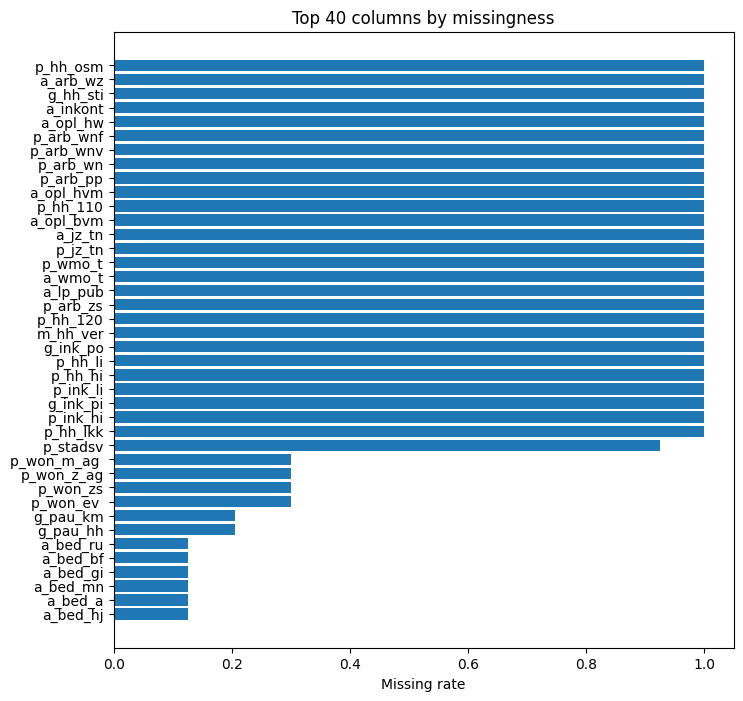

In [185]:
# Top 40 by missingness percentage
top = miss.head(40).sort_values()

plt.figure(figsize=(8,8))
plt.barh(top.index, top.values)
plt.title("Top 40 columns by missingness")
plt.xlabel("Missing rate")
plt.show()


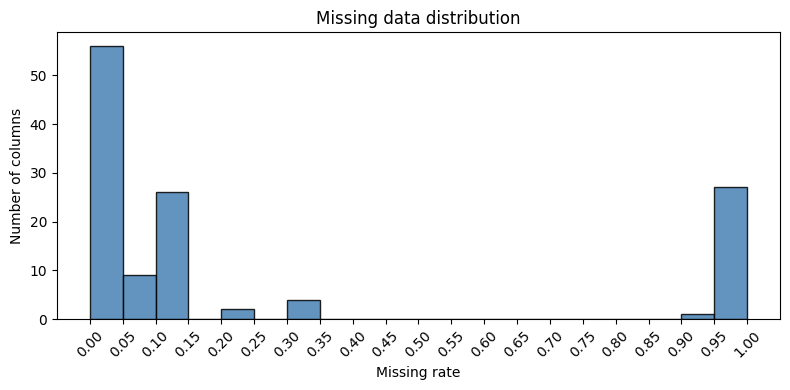

In [186]:
plt.figure(figsize=(8,4))
bins = np.arange(0, 1.01, 0.05)  # 0.05 step bins
plt.hist(miss, bins=bins, edgecolor='k', color="#4682b4", alpha=0.85)
plt.title("Missing data distribution")
plt.xlabel("Missing rate")
plt.ylabel("Number of columns")

xticks = np.arange(0, 1.01, 0.05)
plt.xticks(xticks, rotation=45)
plt.tight_layout()
plt.show()

In [187]:
# Which columns have more than 15% missing values?
cols_over_15pct_missing = miss[miss > 0.15].index.tolist()
print(cols_over_15pct_missing)
print("Missing over 15%:", len(cols_over_15pct_missing))

['m_hh_ver', 'p_arb_zs', 'a_lp_pub', 'a_wmo_t', 'p_wmo_t', 'p_jz_tn', 'a_jz_tn', 'a_opl_bvm', 'a_opl_hvm', 'a_arb_wz', 'p_arb_pp', 'p_arb_wn', 'p_arb_wnv', 'p_arb_wnf', 'a_opl_hw', 'a_inkont', 'g_hh_sti', 'p_hh_120', 'p_hh_110', 'p_hh_osm', 'p_hh_lkk', 'g_ink_po', 'p_hh_li', 'p_hh_hi', 'p_ink_li', 'g_ink_pi', 'p_ink_hi', 'p_stadsv', 'p_won_z_ag', 'p_won_m_ag ', 'p_won_zs', 'p_won_ev ', 'g_pau_km', 'g_pau_hh']
Missing over 15%: 34


In [188]:
# Which columns have less than 15% missing values?
cols_under_15pct_missing = miss[(miss <= 0.15) & (miss > 0)].index.tolist()
print(cols_under_15pct_missing)
print("Missing under 15%:", len(cols_under_15pct_missing))

['a_bed_a', 'a_bed_mn', 'a_bed_ru', 'a_bed_bf', 'a_bed_gi', 'a_bed_hj', 'a_bed_kl', 'a_bed_oq', 'g_wozbag', 'p_huurw', 'p_wcorpw', 'p_ov_hw', 'p_koopw', 'p_bj_mi10', 'p_bj_me10', 'p_mgezw', 'p_leegsw', 'p_1gezw_tw', 'p_1gezw', 'p_1gezw_hvw', 'p_1gezw_2w', 'p_1gezw_hw', 'a_soz_ww', 'a_soz_ow', 'a_soz_ao', 'a_soz_wb', 'g_gas', 'g_ele_tr', 'g_ele', 'g_afs_hp', 'g_3km_sc', 'g_afs_sc', 'g_afs_kv', 'g_afs_gs', 'bev_dich', 'g_hhgro', 'pst_dekp', 'pst_mvp', 'ste_mvs', 'ste_oad', 'p_ste', 'p_geb']
Missing under 15%: 42


### Population column

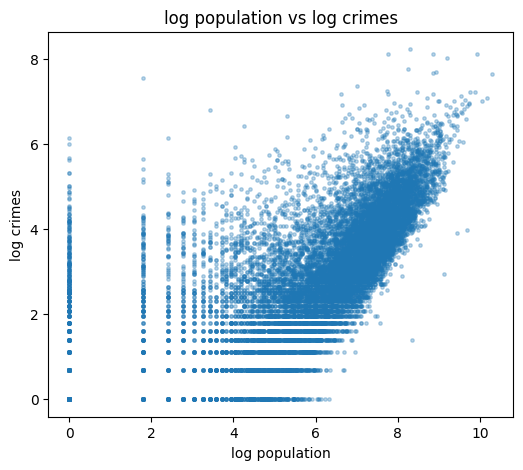

In [189]:
# Scatter plot of log population vs log crimes
x = df["a_inw"]
y = df["crime_count"]

plt.figure(figsize=(6,5))
plt.scatter(np.log1p(x), np.log1p(y), s=6, alpha=0.3)
plt.title("log population vs log crimes")
plt.xlabel("log population")
plt.ylabel("log crimes")
plt.show()


## Feature correlations & Skewness

In [190]:
# Skewness of numeric features (exclude obvious identifiers/targets)
exclude = {
    'crime_count', 'log_crime_count', 'population', 'population_zero',
    'ID', 'merge_key', 'gwb_code', 'gwb_code_10', 'gwb_code_8'
}

num = df.select_dtypes(include=['number']).copy()
cols = [c for c in num.columns if c not in exclude]

skew = num[cols].skew(numeric_only=True).abs().sort_values(ascending=False)
# (Removed) verbose printout.


### Skewness

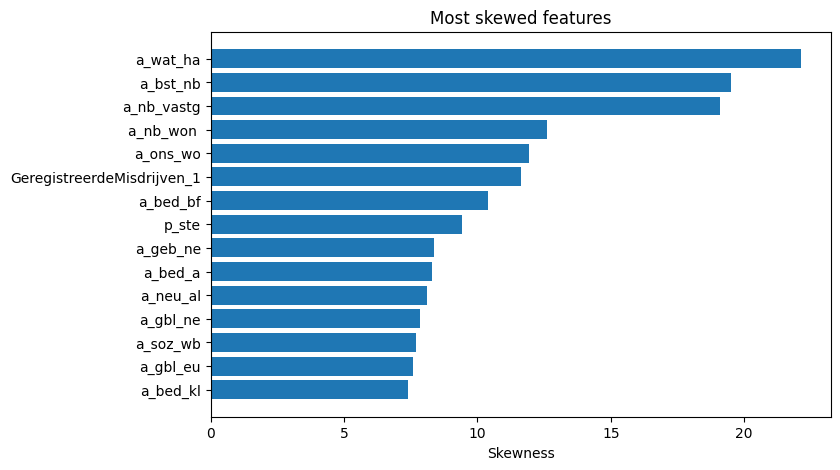

In [191]:
# Top 15 most skewed features
top = skew.head(15).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top.index, top.values)
plt.title("Most skewed features")
plt.xlabel("Skewness")
plt.show()


### Correlation with target

In [192]:
corr = df[num_cols].corrwith(df["log_crime_count"]).sort_values(key=lambda s: s.abs(), ascending=False)
corr.head(15)

a_hh        0.664969
a_woning    0.664121
a_bedv      0.657819
a_soz_ww    0.648184
a_man       0.647196
a_inw       0.646208
a_ongeh     0.645597
a_vrouw     0.643967
a_25_44     0.642167
a_bed_oq    0.640245
a_hh_z_k    0.638278
a_1p_hh     0.631405
a_gesch     0.628403
a_bed_ru    0.627679
ste_mvs    -0.620733
dtype: float64

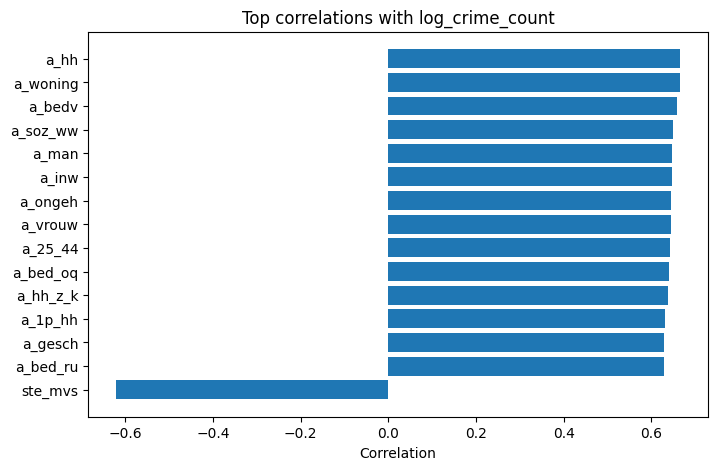

In [193]:
# Top 15 correlations with log_crime_count
top = corr.head(15).sort_values()

plt.figure(figsize=(8,5))
plt.barh(top.index, top.values)
plt.title("Top correlations with log_crime_count")
plt.xlabel("Correlation")
plt.show()


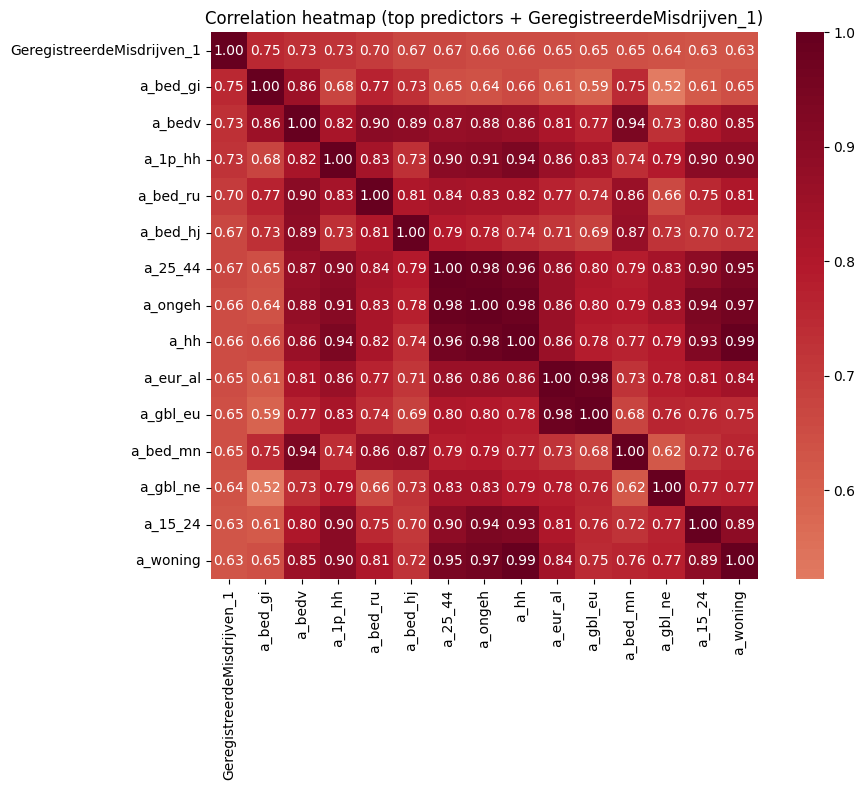

In [202]:
# Correlation heatmap: top 15 predictors + GeregistreerdeMisdrijven_1
target_var = df["GeregistreerdeMisdrijven_1"]
corr_target = df[num_cols].corrwith(target_var).sort_values(key=lambda s: s.abs(), ascending=False)
top_vars_target = corr_target.head(15).index.tolist()

heatmap_data_target = df[top_vars_target].copy()
heatmap_data_target["GeregistreerdeMisdrijven_1"] = target_var
cols_for_heatmap = ["GeregistreerdeMisdrijven_1"] + [c for c in top_vars_target if c != "GeregistreerdeMisdrijven_1"]

plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(heatmap_data_target[cols_for_heatmap].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation heatmap (top predictors + GeregistreerdeMisdrijven_1)")
plt.tight_layout()
plt.show()

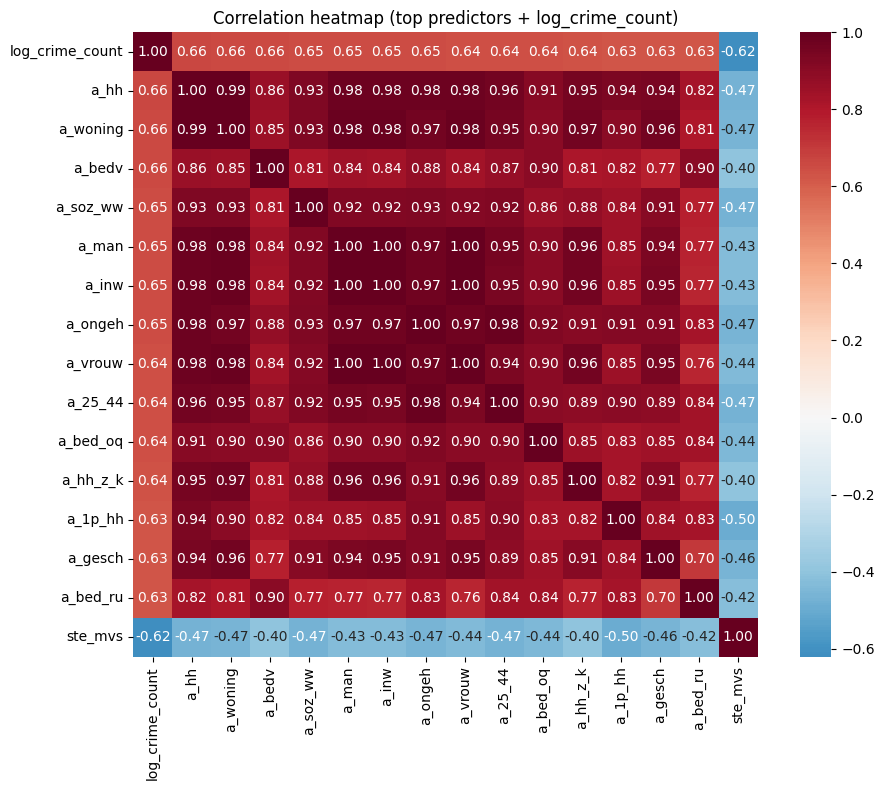

In [195]:
# Correlation heatmap: top 15 predictors + log_crime_count
log_target = df["log_crime_count"]
corr_log = df[num_cols].corrwith(log_target).sort_values(key=lambda s: s.abs(), ascending=False)
top_vars_log = corr_log.head(15).index.tolist()

heatmap_data_log = df[top_vars_log].copy()
heatmap_data_log["log_crime_count"] = log_target
cols_for_heatmap = ["log_crime_count"] + [c for c in top_vars_log if c != "log_crime_count"]

plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(heatmap_data_log[cols_for_heatmap].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation heatmap (top predictors + log_crime_count)")
plt.tight_layout()
plt.show()

### Candidate Predictor Features

In [198]:
# Print all columns of the cleaned dataset
print(list(df.columns))

['gwb_code_10', 'regio', 'gm_naam', 'a_inw', 'a_man', 'a_vrouw', 'a_00_14', 'a_15_24', 'a_25_44', 'a_45_64', 'a_65_oo', 'a_ongeh', 'a_gehuwd', 'a_gesch', 'a_verwed', 'a_nl_all', 'a_eur_al', 'a_neu_al', 'a_geb_nl', 'a_geb_eu', 'a_geb_ne', 'a_gbl_eu', 'a_gbl_ne', 'a_geb', 'p_geb', 'a_ste', 'p_ste', 'a_hh', 'a_1p_hh', 'a_hh_z_k', 'a_hh_m_k', 'g_hhgro', 'bev_dich', 'a_woning', 'a_nb_won ', 'a_vastg', 'a_nb_vastg', 'g_wozbag', 'p_1gezw', 'p_1gezw_tw', 'p_1gezw_hw', 'p_1gezw_2w', 'p_1gezw_hvw', 'p_mgezw', 'p_leegsw', 'p_koopw', 'p_huurw', 'p_wcorpw', 'p_ov_hw', 'p_bj_me10', 'p_bj_mi10', 'g_ele', 'g_ele_tr', 'g_gas', 'p_stadsv', 'p_won_z_ag', 'p_won_m_ag ', 'p_won_zs', 'p_won_ev ', 'a_lp_pub', 'a_ons_po', 'a_ons_vovavo', 'a_ons_mbo', 'a_ons_hbo', 'a_ons_wo', 'a_opl_bvm', 'a_opl_hvm', 'a_opl_hw', 'a_arb_wz', 'p_arb_pp', 'p_arb_wn', 'p_arb_wnv', 'p_arb_wnf', 'p_arb_zs', 'a_inkont', 'g_ink_po', 'g_ink_pi', 'p_ink_li', 'p_ink_hi', 'g_hh_sti', 'p_hh_li', 'p_hh_hi', 'p_hh_lkk', 'p_hh_osm', 'p_hh_11

In [199]:
# Columns not used for prediction
non_predictor_cols = [
    "gwb_code_10", "regio", "gm_naam", "GeregistreerdeMisdrijven_1", "crime_count", "log_crime_count"
]

# Select only numeric columns and drop non-predictor columns
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
predictor_cols = [c for c in numeric_cols if c not in non_predictor_cols]

print(f"Candidate Predictor feature count: {len(predictor_cols)}")

Candidate Predictor feature count: 119


In [200]:
# Columns not used for prediction
non_predictor_cols = [
    "gwb_code_10", "regio", "gm_naam", "GeregistreerdeMisdrijven_1", "crime_count", "log_crime_count"
]

# Select only numeric columns and drop non-predictor columns
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
predictor_cols = [c for c in numeric_cols if c not in non_predictor_cols]

# Exclude features with more than 15% missing values
missing_frac = df[predictor_cols].isnull().mean()
predictor_cols_no_missing = [col for col in predictor_cols if missing_frac[col] <= 0.15]
print(f"Candidate Predictor feature count (excluding >15% missing): {len(predictor_cols_no_missing)}")

Candidate Predictor feature count (excluding >15% missing): 85


## Outputs saved

- **Datasets:** none (EDA reads from `datasets/pre-processing/cleaned_crime_nbh_2024.csv`).
- **Figures:** generated inline in the notebook (no files are written by default).